# Homework 1 — Fase 1: Acquisizione Dati & Data Profiling
## Gentrificazione a Milano: Analisi del Mercato Immobiliare

**Corso:** Master in Business Intelligence & Big Data Analytics

**Obiettivo della Fase 1:** Acquisire i dataset e produrre un report di
data profiling completo.

**Fonti dati:**
- **OMI** — Osservatorio del Mercato Immobiliare (Agenzia delle Entrate),
  via Open Data del Comune di Milano: quotazioni €/m² per zona, 2004–2024
- **Demografiche per NIL** — Comune di Milano, 2011–2023
- **Perimetri zone OMI** — GeoJSON, Comune di Milano
- **Annunci di vendita** — API ufficiale Idealista (accesso ricerca)
- **Locazioni brevi** — Inside Airbnb, snapshot Milano (CC BY 4.0)
- **Mix commerciale** — OpenStreetMap via Overpass (ODbL), opzionale

Tutte le fonti sono ad accesso consentito e riproducibili: nessuna
richiede di aggirare protezioni anti-bot.

---

**Struttura del notebook:**
1. Setup ambiente e librerie
2. Download dataset OMI (compravendita 2024/2, storico 2004–2024)
3. Download perimetri zone OMI (GeoJSON)
4. Download dati demografici per quartiere
5. Acquisizione annunci (API Idealista + Inside Airbnb + OSM)
6. Data Profiling: struttura, missing values, duplicati, outlier, incoerenze
7. Sintesi del profiling

## 1. Setup Ambiente e Librerie

In [1]:
# Installazione dipendenze (decommenta se necessario)
# !pip install pandas requests beautifulsoup4 matplotlib seaborn ipywidgets

In [2]:
import os
import json
import time
import re
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from pathlib import Path

# BUG FIX: 'seaborn-v0_8-whitegrid' non esiste su matplotlib < 3.6
# e i nomi 'seaborn-*' sono stati rimossi in 3.8: senza fallback il
# notebook si interrompe alla prima cella.
for style in ('seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot'):
    if style in plt.style.available:
        plt.style.use(style)
        break

sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Ambiente pronto.")

Ambiente pronto.


In [3]:
# Cartelle di output
BASE_DIR = Path('data/milano-realestate')
RAW_DIR = BASE_DIR / 'raw'
PROFILING_DIR = BASE_DIR / 'profiling'

for d in [RAW_DIR, PROFILING_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Cartelle create sotto: {BASE_DIR}")

Cartelle create sotto: data/milano-realestate


In [4]:
# === Helper: lettura robusta dei CSV open data ===
# I CSV del Comune di Milano hanno tre insidie che il notebook originale
# non gestiva:
#   1. encoding non sempre UTF-8 (da qui il "mojibake" nelle etichette)
#   2. separatore ';' con decimale ',' E migliaia '.' -> servono ENTRAMBI
#      decimal=',' e thousands='.', altrimenti "4.100,50" non viene
#      riconosciuto come numero, la colonna resta di tipo object e
#      l'istogramma piu avanti fallisce
#   3. BOM iniziale che sporca il nome della prima colonna

def read_csv_robust(path, sep=';', decimal=',', thousands='.'):
    """Legge un CSV provando piu encoding e forzando il decimale italiano."""
    last_err = None
    for enc in ('utf-8-sig', 'utf-8', 'cp1252', 'latin-1'):
        try:
            df = pd.read_csv(path, sep=sep, decimal=decimal,
                             thousands=thousands, encoding=enc,
                             low_memory=False)
            if len(df.columns) == 1:      # separatore sbagliato
                continue
            df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]
            print(f"  letto con encoding={enc}: {len(df):,} righe x {len(df.columns)} col.")
            return df
        except (UnicodeDecodeError, pd.errors.ParserError) as e:
            last_err = e
            continue
    raise RuntimeError(f"Impossibile leggere {path}: {last_err}")


def to_numeric_it(series):
    """Converte una colonna testuale con decimale italiano in float."""
    if pd.api.types.is_numeric_dtype(series):
        return series
    return pd.to_numeric(
        series.astype(str)
              .str.replace('.', '', regex=False)
              .str.replace(',', '.', regex=False)
              .str.replace(r'[^0-9.\-]', '', regex=True)
              .replace('', np.nan),
        errors='coerce')


def download_to(url, dest, headers=None, timeout=120, min_bytes=1000):
    """Scarica un file verificando che non sia una pagina di errore HTML."""
    r = requests.get(url, headers=headers, timeout=timeout)
    ctype = r.headers.get('Content-Type', '')
    print(f"HTTP {r.status_code} - {len(r.content):,} bytes - {ctype}")
    if r.status_code != 200 or len(r.content) < min_bytes:
        return False
    # BUG FIX: l'originale salvava anche le pagine di errore HTTP 200
    if 'html' in ctype.lower() and not str(dest).endswith('.html'):
        print("  ATTENZIONE: il server ha restituito HTML, non il dataset.")
        return False
    Path(dest).write_bytes(r.content)
    print(f"  Salvato: {Path(dest).name}")
    return True


def scarica_open_data(url, dest, ckan_id=None, formats=('CSV',), headers=None):
    """
    Scarica una risorsa dal portale open data del Comune di Milano.
    Prova prima l'URL diretto, poi risolve la risorsa via API CKAN.

    BUG FIX rispetto all'originale: lo stesso blocco try/fallback era
    copiato quattro volte con piccole differenze, e in tutti i casi
    l'esito veniva giudicato solo su status_code == 200 - quindi una
    pagina di errore HTML restituita con 200 veniva salvata come se
    fosse il CSV, e l'errore emergeva solo dopo, in read_csv.
    """
    dest = Path(dest)
    if download_to(url, dest, headers=headers):
        return True

    if not ckan_id:
        print("  Nessun id CKAN per il fallback.")
        return False

    print("  Tentativo via API CKAN...")
    try:
        ck = requests.get(
            f"https://dati.comune.milano.it/api/3/action/package_show?id={ckan_id}",
            headers=headers, timeout=30)
        if ck.status_code != 200:
            print(f"  API CKAN fallita: HTTP {ck.status_code}")
            return False
        for res in ck.json()['result']['resources']:
            fmt = (res.get('format') or '').upper()
            if any(f.upper() in fmt for f in formats):
                print(f"  Risorsa trovata ({fmt}): {res['url']}")
                if download_to(res['url'], dest, headers=headers):
                    return True
    except Exception as e:
        print(f"  Fallback CKAN fallito: {e}")
    return False


print("Helper di lettura e download definiti.")

Helper di lettura e download definiti.


## 2. Download Dataset OMI (Open Data Comune di Milano)

Il portale Open Data del Comune di Milano usa il formato CKAN. I dataset OMI provengono dall'Agenzia delle Entrate e contengono le quotazioni immobiliari ufficiali per zona e semestre.

### 2.1 OMI Compravendita — Semestre 2024/2 (DS2940)

In [5]:
# Il server del Comune rifiuta lo User-Agent di default di requests
http_headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/csv,application/geo+json,application/json,*/*;q=0.8',
    'Accept-Language': 'it-IT,it;q=0.9',
}

ok = scarica_open_data(
    url="https://dati.comune.milano.it/dataset/b5bee88f-c567-4978-8a20-2769bdae3835/"
        "resource/fe7d4609-b59d-4ff6-b68e-2f66bf96dfce/"
        "download/ds2940_quotazioni_omi_compravendita_2024_2.csv",
    dest=RAW_DIR / 'omi_compravendita_2024_2.csv',
    ckan_id="ds2940-quotazioni-immobiliari-omi-compravendita-semestre-2024-2",
    headers=http_headers,
)
print(f"Esito: {'OK' if ok else 'FALLITO'}")

HTTP 200 - 47,976 bytes - text/csv
  Salvato: omi_compravendita_2024_2.csv
Esito: OK


In [6]:
# BUG FIX: aggiunto decimal=',' e fallback di encoding.
# Senza decimal=',' Compr_min/Compr_max restavano stringhe e la cella
# dell'istogramma piu avanti falliva con TypeError.
omi_2024_2 = read_csv_robust(RAW_DIR / 'omi_compravendita_2024_2.csv')

# Forza il tipo numerico sulle colonne di prezzo, qualunque sia il formato
for col in [c for c in omi_2024_2.columns if c.startswith(('Compr_', 'Loc_'))]:
    omi_2024_2[col] = to_numeric_it(omi_2024_2[col])

print(f"Righe: {len(omi_2024_2)}, Colonne: {len(omi_2024_2.columns)}")
print(f"Colonne prezzo numeriche: "
      f"{[c for c in omi_2024_2.columns if c.startswith('Compr_')]}")
omi_2024_2.head()

  letto con encoding=utf-8-sig: 446 righe x 18 col.
Righe: 446, Colonne: 18
Colonne prezzo numeriche: ['Compr_min', 'Compr_max']


,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,LinkZona,Cod_Tip,Descr_Tipologia,Stato,Stato_prev,Compr_min,Compr_max,Sup_NL_compr
0,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B12,MI00003228,20,Abitazioni civili,NORMALE,P,8300,10800,L
1,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B12,MI00003228,20,Abitazioni civili,OTTIMO,,10900,14700,L
2,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B12,MI00003228,19,Abitazioni signorili,OTTIMO,P,12000,17500,L
3,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B12,MI00003228,19,Abitazioni signorili,NORMALE,,9000,11900,L
4,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B12,MI00003228,13,Box,NORMALE,P,4600,6800,L


### 2.2 OMI Storico — Compravendita e Locazione 2004–2024 (DS1996)

Questo dataset contiene le quotazioni storiche dal 2004 al 2024, sia per compravendita che per locazione. È la fonte principale per analizzare l'evoluzione dei prezzi nel tempo.

In [7]:
ok = scarica_open_data(
    url="https://dati.comune.milano.it/dataset/1ad8ecfd-5d4a-487d-b2e3-7d45fe9e1274/"
        "resource/90df91fa-9bc9-4100-9192-cb3a2f46fd44/"
        "download/ds1996_quotazioni_omi_compravendita_e_locazione_riepilogo.csv",
    dest=RAW_DIR / 'omi_storico_2004_2024.csv',
    ckan_id="ds1996-quotazioni-immobiliari-omi-compravendita-e-locazione-riepilogo",
    headers=http_headers,
)
print(f"Esito: {'OK' if ok else 'FALLITO'}")

HTTP 200 - 3,545,998 bytes - text/csv
  Salvato: omi_storico_2004_2024.csv
Esito: OK


In [8]:
omi_storico = read_csv_robust(RAW_DIR / 'omi_storico_2004_2024.csv')

for col in [c for c in omi_storico.columns if c.startswith(('Compr_', 'Loc_'))]:
    omi_storico[col] = to_numeric_it(omi_storico[col])

# BUG FIX: 'Anno' puo essere letto come object se contiene semestri tipo "2024/2"
omi_storico['Anno'] = pd.to_numeric(
    omi_storico['Anno'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')

print(f"Righe: {len(omi_storico)}, Colonne: {len(omi_storico.columns)}")
print(f"Anni coperti: {omi_storico['Anno'].min():.0f} - {omi_storico['Anno'].max():.0f}")
if 'Descr_Tipologia' in omi_storico.columns:
    print(f"Tipologie: {omi_storico['Descr_Tipologia'].dropna().unique()[:5]}")
omi_storico.head()

  letto con encoding=utf-8-sig: 26,392 righe x 23 col.
Righe: 26392, Colonne: 23
Anni coperti: 2004 - 2024
Tipologie: ['Abitazioni civili' 'Abitazioni di tipo economico' 'Box'
 'Ville e Villini' 'Magazzini']


,Anno,Periodo,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,LinkZona,Cod_Tip,Descr_Tipologia,Stato,Stato_prev,Compr_min,Compr_max,Sup_NL_compr,Loc_min,Loc_max,Sup_NL_loc
0,2004,2 semestre,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B01,MI00000290,20,Abitazioni civili,NORMALE,P,3850,5450,L,10.2,14.5,L
1,2004,2 semestre,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B01,MI00000290,20,Abitazioni civili,SCADENTE,,3300,4750,L,8.7,12.7,L
2,2004,2 semestre,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B01,MI00000290,20,Abitazioni civili,OTTIMO,,5000,6750,L,13.2,18.0,L
3,2004,2 semestre,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B01,MI00000290,21,Abitazioni di tipo economico,OTTIMO,,4800,6400,L,16.0,21.2,L
4,2004,2 semestre,NORD-OVEST,LOMBARDIA,MI,3015146,C1AA,,F205,MILANO,B,B01,MI00000290,21,Abitazioni di tipo economico,NORMALE,P,3600,5350,L,12.0,17.7,L


### 2.3 Perimetri Zone OMI 2024/1 (DS2831) — GeoJSON

Contiene i confini geografici delle zone OMI, necessari per le visualizzazioni su mappa (choropleth).

In [9]:
ok = scarica_open_data(
    url="https://dati.comune.milano.it/dataset/37e0fb6c-521e-4ecf-9043-f3bfa9400d6d/"
        "resource/cba1ced9-532a-480e-845d-8875ff9cb538/"
        "download/_expl_f205-2024_1.geojson",
    dest=RAW_DIR / 'omi_zone_perimetri.geojson',
    ckan_id="ds2831-zone-e-perimetri-omi-2024-1",
    formats=('GEOJSON', 'JSON'),
    headers=http_headers,
)
print(f"Esito: {'OK' if ok else 'FALLITO'}")

HTTP 200 - 364,358 bytes - application/geo+json
  Salvato: omi_zone_perimetri.geojson
Esito: OK


In [10]:
geojson_path = RAW_DIR / 'omi_zone_perimetri.geojson'

if geojson_path.exists():
    with open(geojson_path, 'r', encoding='utf-8') as f:
        geo_data = json.load(f)
    print(f"Feature totali (zone): {len(geo_data['features'])}")
    print(f"Esempio proprieta: {geo_data['features'][0]['properties']}")
else:
    # BUG FIX: senza questa guardia il notebook si interrompeva con
    # FileNotFoundError, e la cella di sintesi finale falliva su geo_data
    geo_data = {'type': 'FeatureCollection', 'features': []}
    print("GeoJSON non disponibile: proseguo con una collezione vuota.")

Feature totali (zone): 41
Esempio proprieta: {'Name': 'MILANO - Zona OMI B12', 'Anno / Semestre': '2024 / 1', 'Fascia': 'B', 'Zona_Descr': 'CENTRO STORICO -DUOMO, SANBABILA, MONTENAPOLEONE, MISSORI, CAIROLI', 'Zona': 'B12', 'LinkZona': 'MI00003228', 'Cod_tip_prev': '20', 'Descr_tip_prev': 'Abitazioni civili', 'Stato_prev': 'N', 'Microzona': '2'}


## 3. Download Dati Demografici per Quartiere (DS205)

Dataset con indicatori demografici per Nucleo di Identità Locale (NIL) dal 2011 al 2023: popolazione, stranieri, famiglie, nati, morti, immigrati, scuole, area.

In [11]:
ok = scarica_open_data(
    url="https://dati.comune.milano.it/dataset/fcddb7d2-b106-48f5-9a2a-64d3136621dc/"
        "resource/084457a7-ec4b-4a6b-b463-d8ab53c64fbb/"
        "download/ds205_dati_quartieri_2011_2023.csv",
    dest=RAW_DIR / 'demografiche_quartieri.csv',
    ckan_id="ds205-sociale-caratteristiche-demografiche-territoriali-quartiere",
    headers=http_headers,
)
print(f"Esito: {'OK' if ok else 'FALLITO'}")

HTTP 200 - 183,049 bytes - text/csv
  Salvato: demografiche_quartieri.csv
Esito: OK


In [12]:
demografiche = read_csv_robust(RAW_DIR / 'demografiche_quartieri.csv')

demografiche['Anno'] = pd.to_numeric(demografiche['Anno'], errors='coerce')

print(f"Righe: {len(demografiche)}, Colonne: {len(demografiche.columns)}")
print(f"Anni: {demografiche['Anno'].min():.0f} - {demografiche['Anno'].max():.0f}")
print(f"Quartieri unici: {demografiche['Quartiere'].nunique()}")

# BUG FIX: il notebook segnalava "mojibake" nelle etichette come problema
# del dataset. Non lo era: era l'encoding sbagliato in lettura.
sospette = [c for c in demografiche.columns if 'Ã' in c or 'Â' in c]
print(f"Colonne con encoding corrotto residuo: {len(sospette)}")
demografiche.head()

  letto con encoding=utf-8-sig: 1,154 righe x 29 col.
Righe: 1154, Colonne: 29
Anni: 2011 - 2023
Quartieri unici: 89
Colonne con encoding corrotto residuo: 0


,Anno,Quartiere,NIL,Uomini,Donne,Totale,Minori,Stranieri,Famiglie registrate in anagrafe,Famiglie unipersonali registrate in anagrafe,80 e pi— soli fam registrate in anagrafe,Nati vivi,Nati fuori dal matrimonio,Nati con almeno un genitore straniero,Morti,Emigrati,Immigrati,80 e pi—,65 e pi—,Prima cittadinanza,residenti prima cittadinanza,Seconda cittadinanza,residenti seconda cittadinanza,Terza cittadinanza,residenti terza cittadinanza,Scuola dell'infanzia (numero),Scuola primaria (numero),Scuola secondaria di primo grado (numero),Area (metri quadrati)
0,2011,Adriano,17.0,7188.0,7042.0,14230.0,2712.0,2538.0,6942.0,2947.0,243.0,160.0,48.0,48.0,70.0,341.0,896.0,476.0,2141.0,Filippine,449.0,"Cinese, Repubblica Popolare",328.0,Egitto,275.0,4.0,1.0,0.0,2431560.11
1,2011,Affori,80.0,11497.0,11564.0,23061.0,3721.0,6276.0,11974.0,5987.0,634.0,229.0,76.0,102.0,201.0,552.0,994.0,1226.0,4623.0,"Cinese, Repubblica Popolare",1333.0,Egitto,979.0,Filippine,903.0,5.0,3.0,2.0,2070893.65
2,2011,Assiano,87.0,156.0,138.0,294.0,71.0,27.0,121.0,52.0,6.0,4.0,4.0,2.0,1.0,32.0,15.0,8.0,35.0,Paesi Bassi,9.0,Croazia,5.0,"Serbia, Repubblica di",3.0,0.0,0.0,0.0,5844580.12
3,2011,Baggio - Q.re degli Olmi - Q.re Valsesia,55.0,14029.0,15565.0,29594.0,4468.0,4545.0,14459.0,6033.0,914.0,230.0,92.0,89.0,320.0,673.0,909.0,2003.0,7741.0,Filippine,892.0,Per—,687.0,Egitto,488.0,7.0,3.0,2.0,3478599.96
4,2011,Bande Nere,52.0,19693.0,23762.0,43455.0,5994.0,5915.0,23861.0,11846.0,2040.0,347.0,114.0,104.0,593.0,1009.0,1335.0,4443.0,12772.0,Filippine,1253.0,Per—,521.0,Egitto,520.0,14.0,7.0,7.0,2663880.93


## 4. Acquisizione Annunci Immobiliari

### 4.1 Perché non si fa scraping di Immobiliare.it e Idealista.it

Entrambi i portali proteggono le pagine con **Datadome**, un sistema di
bot-detection. Aggirarlo (undetected-chromedriver, playwright-stealth,
browser non-headless su display virtuale, retry sulla pagina di CAPTCHA)
significa **eludere una misura tecnica di controllo dell'accesso**, non
"risolvere un bug". Inoltre:

- I **Termini di Servizio** di entrambi i portali vietano esplicitamente
  l'estrazione automatizzata dei contenuti; gli annunci sono tutelati anche
  come banca dati (art. 102-bis L. 633/1941, dir. 96/9/CE).
- Per un elaborato accademico il metodo è **non riproducibile**: il
  fingerprint cambia, l'anti-bot si aggiorna, e chi corregge l'homework non
  riesce a rieseguire il notebook.

### 4.2 Fonti sostitutive utilizzate

| Fonte | Cosa fornisce | Licenza / accesso |
|---|---|---|
| **API ufficiale Idealista** | Annunci di vendita strutturati (prezzo, mq, locali, coordinate) | Chiave gratuita per uso ricerca: `developers.idealista.com/access-request` |
| **Inside Airbnb — Milano** | Locazioni brevi per quartiere: proxy classico della pressione turistica | CC BY 4.0, `insideairbnb.com/get-the-data` |
| **OMI (già scaricato sopra)** | Quotazioni ufficiali €/m² per zona, serie 2004–2024 | Open data Comune di Milano |
| **OpenStreetMap / Overpass** | Mix commerciale (bar, caffè specialty, palestre, gallerie) | ODbL |

Per l'analisi di gentrificazione questo set è **metodologicamente più solido**
degli annunci scrapati: OMI dà la serie storica ventennale che gli annunci
non hanno, e Inside Airbnb è la fonte usata nella letteratura accademica
sul tema (Wachsmuth & Weisler, Cocola-Gant).

In [13]:
# === SETUP acquisizione annunci (nessuna automazione browser) ===
# !pip install -q requests pandas

import time
from typing import List, Dict

# Schema unico per gli annunci di vendita, qualunque sia la fonte.
# Garantisce che df_listings abbia sempre le colonne attese dalle celle
# di profiling a valle, anche se una fonte non restituisce nulla.
LISTING_SCHEMA = [
    'title', 'price_eur', 'price_per_m2_eur', 'area_m2', 'rooms',
    'bathrooms', 'floor', 'zone_neighborhood', 'property_type',
    'description', 'link', 'listing_id', 'listing_date', 'source',
]

def empty_listing() -> Dict:
    """Record vuoto conforme allo schema."""
    return {k: None for k in LISTING_SCHEMA}

print(f"Schema annunci definito ({len(LISTING_SCHEMA)} campi).")

Schema annunci definito (14 campi).


### 4.3 Idealista — API ufficiale

Credenziali ottenute da <https://developers.idealista.com/access-request>.

**Limiti del piano gratuito, che condizionano il disegno del codice:**

| Vincolo | Valore | Come e gestito qui |
|---|---|---|
| Richieste al mese | **100** | contatore persistente su disco, con blocco prima di sforare |
| Frequenza | **1 req/sec** | attesa forzata di 1,05 s tra le chiamate |
| Annunci per richiesta | 50 (`maxItems`) | una pagina per zona |
| Durata del token | ~12 h | token in cache, non richiesto a ogni chiamata |

Cento richieste al mese sono **poche**: otto zone per una singola esecuzione
sono l'8% del budget mensile, e ogni volta che riesegui la cella le consumi di
nuovo. Per questo le risposte vengono **salvate su disco**: rieseguire il
notebook rilegge la cache e non spende quota. Per forzare un aggiornamento
serve `force_refresh=True`.

Il formato della richiesta segue l'esempio della documentazione, che usa
`multipart/form-data` (i `-F` del `curl`), non `x-www-form-urlencoded`.
L'endpoint e `/3.5/it/search` — la `it` e il paese, l'esempio della doc usa
`es` perche e per la Spagna.

> **Credenziali.** Sono lette prima dalle variabili d'ambiente o dai Colab
> secrets, e solo in ultima istanza dalle costanti nella cella sotto. Prima di
> consegnare l'elaborato, svuota quelle costanti: altrimenti la chiave viaggia
> dentro il file `.ipynb` e in tutta la cronologia git del progetto.

In [14]:
import base64
import hashlib
from datetime import datetime

# ============================================================
#  CREDENZIALI
# ------------------------------------------------------------
#  Ordine di lettura: variabile d'ambiente -> Colab secrets ->
#  costanti qui sotto. SVUOTA le costanti prima di consegnare:
#  il file .ipynb viene letto da chiunque lo riceva.
# ============================================================
IDEALISTA_KEY_INLINE    = '0032rxjnesdnbdom36ymvox48e1kj15n'
IDEALISTA_SECRET_INLINE = 'VLS9eKbtfT0o'


def _leggi_credenziale(nome, fallback):
    val = os.environ.get(nome)
    if val:
        return val
    try:                                   # Colab secrets
        from google.colab import userdata
        val = userdata.get(nome)
        if val:
            return val
    except Exception:
        pass
    return fallback


IDEALISTA_KEY    = _leggi_credenziale('IDEALISTA_KEY', IDEALISTA_KEY_INLINE)
IDEALISTA_SECRET = _leggi_credenziale('IDEALISTA_SECRET', IDEALISTA_SECRET_INLINE)

TOKEN_URL  = 'https://api.idealista.com/oauth/token'
SEARCH_URL = 'https://api.idealista.com/3.5/it/search'   # 'it' = Italia

# --- Limiti del piano gratuito ---
QUOTA_MENSILE     = 100      # richieste/mese
INTERVALLO_MIN    = 1.05     # secondi tra due chiamate (limite: 1 req/sec)

CACHE_DIR = RAW_DIR.parent / 'cache' / 'idealista'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
QUOTA_FILE = CACHE_DIR / 'quota.json'

_token_cache = {'token': None, 'scade_a': 0.0}
_ultima_chiamata = {'t': 0.0}


# ------------------------------------------------------------
#  Contatore di quota, persistente tra le esecuzioni
# ------------------------------------------------------------
def quota_stato():
    mese = datetime.now().strftime('%Y-%m')
    if QUOTA_FILE.exists():
        try:
            d = json.loads(QUOTA_FILE.read_text())
            if d.get('mese') == mese:
                return d
        except json.JSONDecodeError:
            pass
    return {'mese': mese, 'usate': 0}


def quota_incrementa(n=1):
    d = quota_stato()
    d['usate'] += n
    QUOTA_FILE.write_text(json.dumps(d))
    return d


def quota_residua():
    return QUOTA_MENSILE - quota_stato()['usate']


def quota_report():
    d = quota_stato()
    print(f"Quota Idealista {d['mese']}: {d['usate']}/{QUOTA_MENSILE} usate, "
          f"{QUOTA_MENSILE - d['usate']} residue")


# ------------------------------------------------------------
#  Autenticazione (token valido ~12 h, quindi va messo in cache)
# ------------------------------------------------------------
def idealista_get_token(force=False):
    if not force and _token_cache['token'] and time.time() < _token_cache['scade_a']:
        return _token_cache['token']

    basic = base64.b64encode(
        f'{IDEALISTA_KEY}:{IDEALISTA_SECRET}'.encode()).decode()
    r = requests.post(
        TOKEN_URL,
        headers={'Authorization': f'Basic {basic}',
                 'Content-Type': 'application/x-www-form-urlencoded;charset=UTF-8'},
        data={'grant_type': 'client_credentials', 'scope': 'read'},
        timeout=30,
    )
    r.raise_for_status()
    p = r.json()
    _token_cache['token'] = p['access_token']
    # margine di 5 minuti prima della scadenza dichiarata
    _token_cache['scade_a'] = time.time() + p.get('expires_in', 43200) - 300
    print(f"  Token ottenuto (valido {p.get('expires_in', 0) / 3600:.0f} h)")
    return _token_cache['token']


# ------------------------------------------------------------
#  Ricerca, con cache su disco e rispetto del rate limit
# ------------------------------------------------------------
def _chiave_cache(params):
    grezzo = json.dumps(params, sort_keys=True)
    return hashlib.sha256(grezzo.encode()).hexdigest()[:16]


def idealista_search(center, distance=2000, num_page=1, max_items=50,
                     operation='sale', property_type='homes',
                     force_refresh=False, extra=None):
    """
    Una chiamata di ricerca. Ritorna il JSON dell'API, oppure None se la
    quota mensile e esaurita.

    La documentazione usa multipart/form-data (i -F del curl), quindi qui si
    passa `files=` con tuple (None, valore): requests genera il multipart e il
    boundary corretto. Non impostare Content-Type a mano, o il boundary manca.
    """
    params = {'country': 'it', 'operation': operation,
              'propertyType': property_type, 'center': center,
              'distance': distance, 'maxItems': max_items,
              'numPage': num_page, 'locale': 'it'}
    if extra:
        params.update(extra)

    # 1. cache su disco: rieseguire il notebook non deve consumare quota
    cache_file = CACHE_DIR / f'{_chiave_cache(params)}.json'
    if cache_file.exists() and not force_refresh:
        d = json.loads(cache_file.read_text())
        print(f"    (da cache: {cache_file.name})")
        return d

    # 2. blocco di sicurezza sulla quota
    if quota_residua() <= 0:
        print('    QUOTA MENSILE ESAURITA: chiamata non effettuata.')
        return None

    # 3. rate limit: 1 richiesta al secondo
    attesa = INTERVALLO_MIN - (time.time() - _ultima_chiamata['t'])
    if attesa > 0:
        time.sleep(attesa)

    token = idealista_get_token()
    r = requests.post(
        SEARCH_URL,
        headers={'Authorization': f'Bearer {token}'},
        files={k: (None, str(v)) for k, v in params.items()},
        timeout=60,
    )
    _ultima_chiamata['t'] = time.time()
    quota_incrementa()

    if r.status_code == 429:
        print('    HTTP 429: limite di frequenza superato, rallenta.')
        return None
    if r.status_code == 403:
        print('    HTTP 403: credenziali non valide o quota esaurita lato server.')
        return None
    r.raise_for_status()

    d = r.json()
    cache_file.write_text(json.dumps(d, ensure_ascii=False))
    return d


def normalize_idealista(el, zone_name):
    """Mappa un elemento dell'API sullo schema comune degli annunci."""
    rec = empty_listing()
    price, size = el.get('price'), el.get('size')
    rec.update({
        'title': (el.get('suggestedTexts') or {}).get('title') or el.get('address'),
        'price_eur': float(price) if price is not None else None,
        'area_m2': float(size) if size else None,
        'price_per_m2_eur': el.get('priceByArea'),
        'rooms': el.get('rooms'),
        'bathrooms': el.get('bathrooms'),
        'floor': el.get('floor'),
        'zone_neighborhood': el.get('district') or el.get('neighborhood') or zone_name,
        'property_type': el.get('propertyType'),
        'description': (el.get('description') or '')[:500],
        'link': el.get('url'),
        'listing_id': str(el.get('propertyCode', '')),
        'listing_date': None,
        'source': 'Idealista API',
    })
    return rec


# Centri geografici delle zone di Milano da interrogare (lat,lon).
# Ogni zona = 1 richiesta = 1% della quota mensile.
MILANO_ZONES = [
    ('45.4642,9.1900', 'Centro / Duomo'),
    ('45.4900,9.1880', 'Isola / Porta Nuova'),
    ('45.4520,9.1830', 'Porta Romana'),
    ('45.4520,9.1720', 'Navigli'),
    ('45.4780,9.2260', 'Lambrate / Citta Studi'),
    ('45.4430,9.1350', 'Lorenteggio'),
    ('45.5050,9.1600', 'Bovisa'),
    ('45.4780,9.1250', 'San Siro'),
]


def fetch_idealista_api(zones=MILANO_ZONES [:8], max_richieste=8,
                        distance=2000, force_refresh=False):
    """
    Scarica annunci di vendita via API ufficiale.

    max_richieste limita quante chiamate NUOVE puo fare questa esecuzione:
    le risposte gia in cache non contano. E una protezione contro il consumo
    accidentale della quota mensile rieseguendo la cella.
    """
    if not IDEALISTA_KEY or not IDEALISTA_SECRET:
        print('Credenziali Idealista assenti: fonte saltata.')
        return []

    quota_report()
    if quota_residua() <= 0:
        print('Nessuna richiesta possibile questo mese. Verranno usate solo '
              'le risposte gia in cache.')

    out, nuove = [], 0
    for center, zone_name in zones:
        # NB: espressione calcolata fuori dall'f-string. Un'espressione
        # multilinea DENTRO un'f-string richiede Python 3.12 (PEP 701) e
        # solleverebbe SyntaxError su Colab con Python 3.11.
        params_previsti = {'country': 'it', 'operation': 'sale',
                           'propertyType': 'homes', 'center': center,
                           'distance': distance, 'maxItems': 50,
                           'numPage': 1, 'locale': 'it'}
        cache_file = CACHE_DIR / (_chiave_cache(params_previsti) + '.json')
        in_cache = cache_file.exists() and not force_refresh

        if not in_cache and nuove >= max_richieste:
            print(f'  {zone_name:24s} saltata (limite di {max_richieste} '
                  f'richieste nuove per esecuzione)')
            continue

        try:
            data = idealista_search(center, distance=distance,
                                    force_refresh=force_refresh)
            if data is None:
                continue
            if not in_cache:
                nuove += 1
            elementi = data.get('elementList', [])
            out.extend(normalize_idealista(el, zone_name) for el in elementi)
            print(f'  {zone_name:24s} {len(elementi):3d} annunci '
                  f'(totale in zona: {data.get("total", "?")})')
        except Exception as e:
            print(f'  {zone_name:24s} errore: {type(e).__name__}: {e}')

    print(f'\nRichieste nuove effettuate: {nuove}')
    quota_report()
    return out


print('Client API Idealista pronto.')
quota_report()

Client API Idealista pronto.
Quota Idealista 2026-08: 0/100 usate, 100 residue


### 4.4 Immobiliare.it — API Insights (Market Explorer)

Immobiliare.it ha due famiglie di API, **nessuna delle quali serve a leggere
gli annunci dal portale pubblico**:

| API | Direzione | A chi serve |
|---|---|---|
| `feed.immobiliare.it` | **scrittura**: le agenzie *pubblicano* i loro annunci sul portale (REST-XML, Basic auth, IP whitelist) | agenzie clienti del portale |
| **Immobiliare.it Insights** (Realitycs) | **lettura**: dati di mercato aggregati | clienti B2B con contratto |

Quella utile qui è la seconda. Il servizio **Market Explorer**
(`ws-osservatorio.realitycs.it`) espone serie storiche di prezzi richiesti,
volume annunci, dati di domanda (ricerche e contatti) e prezzi di
compravendita, **aggregati per zona geografica** fino al livello di microzona
comunale — con una tassonomia che include anche le **zone OMI**.

**Cosa comporta:**

- È un prodotto commerciale: **non c'è registrazione self-service né piano
  gratuito**. Le credenziali (`clientID`, `secretkey`, `username`, `password`)
  arrivano dopo un contratto, tramite il modulo su
  <https://www.immobiliare.it/insights/dati-api/>. Per una tesi vale la pena
  chiedere se prevedono un accesso accademico, ma non darlo per scontato.
- I dati sono **aggregati per zona, non annunci singoli**. Per la
  gentrificazione questo è un vantaggio, non un limite: ottieni la serie
  storica trimestrale che uno snapshot di annunci non può darti, con la stessa
  struttura di OMI, quindi i due dataset si confrontano direttamente.
- La documentazione è pubblica: <https://insights.immobiliare.it/webdocs/>

**Nota sui wrapper "API Immobiliare.it" che trovi su RapidAPI**: non sono
ufficiali. Sono scraper rivenduti come API — stesso problema di ToS di prima,
in più senza garanzie sulla provenienza del dato, che in un elaborato
accademico non è citabile.

Il client qui sotto implementa gli endpoint che ho verificato sulla
documentazione. Se non hai le credenziali, la cella si salta senza errori.

In [15]:
# === Client Immobiliare.it Insights — Market Explorer ===
# Documentazione: https://insights.immobiliare.it/webdocs/
# Endpoint verificati su doc:
#   POST /oauth/token
#   GET  /api/taxonomies/geo/{nation}/ty_zone/{ty_zone}/id_zone/{id_zone}
#   POST /api/price/history
# Gli altri servizi (ads, sales-price, sales-volume, search-data) seguono lo
# stesso schema: usa il metodo generico .post() con il path che trovi in doc.

INSIGHTS_BASE = 'https://ws-osservatorio.realitycs.it'

INSIGHTS_CLIENT_ID = os.environ.get('INSIGHTS_CLIENT_ID', '')
INSIGHTS_SECRET    = os.environ.get('INSIGHTS_SECRET', '')
INSIGHTS_USERNAME  = os.environ.get('INSIGHTS_USERNAME', '')
INSIGHTS_PASSWORD  = os.environ.get('INSIGHTS_PASSWORD', '')


class InsightsClient:
    """
    Client minimale per le API Immobiliare.it Insights.

    ATTENZIONE al token: la documentazione avverte che il token dura 4 ore e
    che autenticarsi prima di ogni chiamata puo far scattare i sistemi di
    protezione e portare a un ban temporaneo. Qui il token viene quindi
    ottenuto una volta sola e riusato finche non scade.
    """

    def __init__(self, client_id, secret, username, password, base=INSIGHTS_BASE):
        self.base = base.rstrip('/')
        self._auth = (client_id, secret)
        self._cred = {'grant_type': 'password',
                      'username': username, 'password': password}
        self._token = None
        self._expires_at = 0.0

    # --- autenticazione -------------------------------------------------
    def _get_token(self):
        if self._token and time.time() < self._expires_at - 300:
            return self._token          # margine di 5 minuti prima della scadenza

        r = requests.post(
            f'{self.base}/oauth/token',
            auth=self._auth,            # HTTP Basic: clientID:secretkey
            headers={'Content-Type': 'application/x-www-form-urlencoded'},
            data=self._cred,
            timeout=30,
        )
        r.raise_for_status()
        payload = r.json()
        self._token = payload['access_token']
        self._expires_at = time.time() + payload.get('expires_in', 14399)
        print(f"  Token ottenuto, valido {payload.get('expires_in', 0)/3600:.1f} ore")
        return self._token

    def _headers(self):
        return {'Authorization': f'Bearer {self._get_token()}',
                'Content-Type': 'application/json'}

    # --- chiamate generiche ---------------------------------------------
    def get(self, path, timeout=60):
        r = requests.get(f'{self.base}{path}', headers=self._headers(), timeout=timeout)
        r.raise_for_status()
        return r.json()

    def post(self, path, payload, timeout=60):
        r = requests.post(f'{self.base}{path}', headers=self._headers(),
                          json=payload, timeout=timeout)
        r.raise_for_status()
        return r.json()

    # --- tassonomia geografica ------------------------------------------
    def sottozone(self, ty_zone, id_zone, nation='IT'):
        """Elenco delle zone al livello immediatamente inferiore."""
        path = f'/api/taxonomies/geo/{nation}/ty_zone/{ty_zone}/id_zone/{id_zone}'
        return self.get(path).get('items', [])

    def trova(self, ty_zone, id_zone, nome, nation='IT'):
        """Cerca per nome dentro le sottozone. Ritorna il record o None."""
        for z in self.sottozone(ty_zone, id_zone, nation=nation):
            if str(z.get('nome', '')).strip().lower() == nome.strip().lower():
                return z
        return None

    # --- serie storica dei prezzi richiesti ------------------------------
    def price_history(self, ty_zone, id_zone, year, month,
                      contract=1, window='1M', typology=None, nation='IT'):
        """
        contract: 1 = vendita, 2 = affitto (verifica su /api/taxonomies)
        typology: codice tipologia immobiliare, opzionale
        """
        payload = {'ty_zone': ty_zone, 'id_zone': str(id_zone),
                   'window': window, 'contract': contract,
                   'year': year, 'month': month, 'nation': nation}
        if typology is not None:
            payload['typology'] = typology
        return self.post('/api/price/history', payload)


def insights_price_history_to_df(risposta, zona_nome=''):
    """
    Appiattisce la risposta di /api/price/history in un DataFrame tidy.
    La risposta annida tre viste: serie complessiva (price_sqm_avg),
    breakdown per stato di manutenzione e breakdown per numero di locali.
    """
    righe = []
    for item in risposta.get('items', []):

        for p in item.get('price_sqm_avg', []):
            righe.append({'zona': zona_nome, 'vista': 'totale', 'categoria': None,
                          'anno': p.get('year'), 'mese': p.get('month'),
                          'prezzo_mq': p.get('price_avg'),
                          'prezzo_mq_in': p.get('price_avgin'),
                          'prezzo_mq_out': p.get('price_avgout')})

        for vista in ('maintenance_status', 'rooms'):
            for categoria, serie in (item.get(vista) or {}).items():
                for p in serie:
                    righe.append({'zona': zona_nome, 'vista': vista,
                                  'categoria': categoria,
                                  'anno': p.get('year'), 'mese': p.get('month'),
                                  'prezzo_mq': p.get('price_avg'),
                                  'prezzo_mq_in': p.get('price_avgin'),
                                  'prezzo_mq_out': p.get('price_avgout')})

    df = pd.DataFrame(righe)
    if not df.empty:
        # data trimestrale ricostruita da anno+mese
        df['periodo'] = pd.to_datetime(
            dict(year=df['anno'], month=df['mese'], day=1), errors='coerce')
        df = df.sort_values(['zona', 'vista', 'categoria', 'periodo'])
    return df


def fetch_immobiliare_insights(anno=2025, mese=12, max_microzone=8):
    """
    Scarica da Market Explorer la serie storica dei prezzi richiesti per
    Milano comune e per le sue microzone. Ritorna un DataFrame vuoto se
    mancano le credenziali.

    Codici ISTAT usati per la navigazione (confermati dal formato degli id
    negli esempi di documentazione): Lombardia = 3, provincia Milano = 15.
    Il codice verifica comunque per nome, quindi se gli id cambiano se ne
    accorge invece di scaricare la zona sbagliata.
    """
    if not all([INSIGHTS_CLIENT_ID, INSIGHTS_SECRET,
                INSIGHTS_USERNAME, INSIGHTS_PASSWORD]):
        print("Credenziali Insights assenti: fonte saltata.")
        print("Sono un prodotto B2B su contratto, non c'e registrazione libera:")
        print("  https://www.immobiliare.it/insights/dati-api/")
        return pd.DataFrame()

    cli = InsightsClient(INSIGHTS_CLIENT_ID, INSIGHTS_SECRET,
                         INSIGHTS_USERNAME, INSIGHTS_PASSWORD)

    try:
        # 1. Lombardia (reg 3) -> provincia di Milano
        prov = cli.trova('reg', 3, 'Milano')
        if prov is None:
            print("Provincia di Milano non trovata sotto la regione 3.")
            print("Ispeziona con: cli.sottozone('reg', 3)")
            return pd.DataFrame()

        # 2. provincia -> comune di Milano
        com = cli.trova('pro', prov['id'], 'Milano')
        if com is None:
            print(f"Comune di Milano non trovato nella provincia {prov['id']}.")
            return pd.DataFrame()
        print(f"Comune di Milano: id_zone={com['id']}")

        blocchi = []

        # 3. serie storica del comune nel suo insieme
        r = cli.price_history('com', com['id'], year=anno, month=mese)
        blocchi.append(insights_price_history_to_df(r, 'Milano (comune)'))
        print(f"  Milano (comune): {len(blocchi[-1])} osservazioni")

        # 4. microzone comunali
        micro = cli.sottozone('com', com['id'])
        print(f"  Microzone disponibili: {len(micro)} "
              f"(ne interrogo {min(len(micro), max_microzone)})")

        for z in micro[:max_microzone]:
            try:
                r = cli.price_history('mic', z['id'], year=anno, month=mese)
                d = insights_price_history_to_df(r, z.get('nome', z['id']))
                blocchi.append(d)
                print(f"    {z.get('nome', z['id']):28s} {len(d):4d} oss.")
            except Exception as ex:
                print(f"    {z.get('nome', z['id']):28s} errore: {ex}")
            time.sleep(1.0)

        df = pd.concat([b for b in blocchi if not b.empty], ignore_index=True) \
             if any(not b.empty for b in blocchi) else pd.DataFrame()

    except Exception as ex:
        print(f"Errore Insights: {ex}")
        return pd.DataFrame()

    if not df.empty:
        df.to_csv(RAW_DIR / 'immobiliare_insights_prezzi.csv',
                  index=False, encoding='utf-8')
        print(f"\nSalvato: immobiliare_insights_prezzi.csv ({len(df)} righe)")
    return df


print("Client Immobiliare.it Insights pronto.")

Client Immobiliare.it Insights pronto.


### 4.5 Inside Airbnb — Milano

Dataset pubblico sotto CC BY 4.0, aggiornato circa ogni trimestre.
`listings.csv` (versione *visualisations*) contiene per ogni annuncio:
quartiere, coordinate, tipo di stanza, prezzo/notte, numero di recensioni,
disponibilità annua e conteggio annunci per host.

Per la gentrificazione gli indicatori chiave sono la **densità di interi
appartamenti** per quartiere e la **quota di host multi-annuncio**
(`calculated_host_listings_count > 1`), che segnalano sottrazione di stock
dal mercato residenziale.

**L'URL contiene la data dello snapshot e cambia a ogni rilascio**:
prendi quello corrente da <https://insideairbnb.com/get-the-data> e
incollalo qui sotto.

In [16]:
# URL dello snapshot Inside Airbnb per Milano.
# Verifica/aggiorna la data su https://insideairbnb.com/get-the-data
AIRBNB_URL = ("https://data.insideairbnb.com/italy/lombardy/milan/"
              "2025-06-19/visualisations/listings.csv")


def fetch_inside_airbnb(url: str = AIRBNB_URL) -> pd.DataFrame:
    """Scarica e normalizza lo snapshot Inside Airbnb di Milano."""
    dest = RAW_DIR / 'airbnb_milano_listings.csv'

    if dest.exists() and dest.stat().st_size > 10_000:
        print(f"Uso il file gia presente: {dest.name}")
    else:
        try:
            r = requests.get(url, headers=http_headers, timeout=120)
            print(f"HTTP {r.status_code} - {len(r.content):,} bytes")
            if r.status_code != 200 or len(r.content) < 10_000:
                print("Download fallito: controlla la data dello snapshot "
                      "su https://insideairbnb.com/get-the-data")
                return pd.DataFrame()
            dest.write_bytes(r.content)
            print(f"Salvato: {dest.name}")
        except Exception as e:
            print(f"Errore di rete: {e}")
            return pd.DataFrame()

    # Inside Airbnb usa la virgola come separatore e UTF-8
    df = pd.read_csv(dest, encoding='utf-8')
    print(f"Righe: {len(df):,} | Colonne: {len(df.columns)}")

    # 'price' puo arrivare come stringa "$1,234.00" oppure gia numerico
    if 'price' in df.columns and not pd.api.types.is_numeric_dtype(df['price']):
        df['price'] = (df['price'].astype(str)
                       .str.replace(r'[^0-9.]', '', regex=True)
                       .replace('', np.nan)
                       .astype(float))

    # Indicatore: host con piu di un annuncio = gestione professionale
    if 'calculated_host_listings_count' in df.columns:
        df['host_multi_listing'] = df['calculated_host_listings_count'] > 1

    return df


print("Loader Inside Airbnb pronto.")

Loader Inside Airbnb pronto.


### 4.6 OpenStreetMap — mix commerciale (opzionale)

Il ricambio degli esercizi commerciali è uno degli indicatori più citati in
letteratura: aumento di caffetterie specialty, ristoranti etnici di fascia
alta, palestre boutique e gallerie d'arte. Overpass API è pubblica, non
richiede chiave, e va interrogata con parsimonia (una query per categoria,
non in loop stretto).

In [17]:
OVERPASS_URL = 'https://overpass-api.de/api/interpreter'

# Bounding box di Milano: sud, ovest, nord, est
MILANO_BBOX = (45.386, 9.040, 45.536, 9.278)


def fetch_osm_pois(amenity_filters=None) -> pd.DataFrame:
    """Scarica POI commerciali da OpenStreetMap via Overpass."""
    if amenity_filters is None:
        amenity_filters = [
            ('amenity', 'cafe'),
            ('amenity', 'bar'),
            ('amenity', 'restaurant'),
            ('leisure', 'fitness_centre'),
            ('shop',    'art'),
            ('tourism', 'gallery'),
        ]

    s, w, n, e = MILANO_BBOX
    parts = [f'node["{k}"="{v}"]({s},{w},{n},{e});' for k, v in amenity_filters]
    query = f'[out:json][timeout:90];({"".join(parts)});out center;'

    try:
        r = requests.post(OVERPASS_URL, data={'data': query}, timeout=120)
        r.raise_for_status()
        elements = r.json().get('elements', [])
    except Exception as ex:
        print(f"Overpass non raggiungibile: {ex}")
        return pd.DataFrame()

    rows = []
    for el in elements:
        tags = el.get('tags', {})
        rows.append({
            'osm_id': el.get('id'),
            'name': tags.get('name'),
            'category': (tags.get('amenity') or tags.get('leisure')
                         or tags.get('shop') or tags.get('tourism')),
            'lat': el.get('lat') or el.get('center', {}).get('lat'),
            'lon': el.get('lon') or el.get('center', {}).get('lon'),
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df.to_csv(RAW_DIR / 'osm_poi_milano.csv', index=False, encoding='utf-8')
        print(f"POI scaricati: {len(df):,}")
        print(df['category'].value_counts().to_dict())
    return df


print("Loader OpenStreetMap pronto. Esegui fetch_osm_pois() quando serve.")

Loader OpenStreetMap pronto. Esegui fetch_osm_pois() quando serve.


In [18]:
# === ESECUZIONE acquisizione annunci ===
all_listings = []

print("=" * 55)
print("IDEALISTA — API ufficiale")
print("=" * 55)
all_listings.extend(fetch_idealista_api())
print(f"\nAnnunci di vendita raccolti: {len(all_listings)}")

print()
print("=" * 55)
print("IMMOBILIARE.IT INSIGHTS — Market Explorer")
print("=" * 55)
df_insights = fetch_immobiliare_insights()

print()
print("=" * 55)
print("INSIDE AIRBNB — Milano")
print("=" * 55)
df_airbnb = fetch_inside_airbnb()

print()
print("=" * 55)
print("RIEPILOGO")
print("=" * 55)
print(f"Annunci di vendita (Idealista API): {len(all_listings)}")
print(f"Annunci Airbnb (Inside Airbnb):     {len(df_airbnb)}")
print(f"Serie prezzi Insights:              {len(df_insights)}")

if all_listings:
    zone_counts = {}
    for a in all_listings:
        z = a.get('zone_neighborhood') or '?'
        zone_counts[z] = zone_counts.get(z, 0) + 1
    print(f"Vendita per zona: {zone_counts}")

if not df_airbnb.empty and 'neighbourhood' in df_airbnb.columns:
    print("\nTop 10 quartieri per numero di annunci Airbnb:")
    print(df_airbnb['neighbourhood'].value_counts().head(10).to_string())

IDEALISTA — API ufficiale
Quota Idealista 2026-08: 0/100 usate, 100 residue
  Token ottenuto (valido 12 h)
  Centro / Duomo            50 annunci (totale in zona: 1705)
  Isola / Porta Nuova       50 annunci (totale in zona: 2149)
  Porta Romana              50 annunci (totale in zona: 1595)
  Navigli                   50 annunci (totale in zona: 1721)
  Lambrate / Citta Studi    50 annunci (totale in zona: 2157)
  Lorenteggio               50 annunci (totale in zona: 938)
  Bovisa                    50 annunci (totale in zona: 1402)
  San Siro                  50 annunci (totale in zona: 838)

Richieste nuove effettuate: 8
Quota Idealista 2026-08: 8/100 usate, 92 residue

Annunci di vendita raccolti: 400

IMMOBILIARE.IT INSIGHTS — Market Explorer
Credenziali Insights assenti: fonte saltata.
Sono un prodotto B2B su contratto, non c'e registrazione libera:
  https://www.immobiliare.it/insights/dati-api/

INSIDE AIRBNB — Milano
HTTP 200 - 3,842,927 bytes
Salvato: airbnb_milano_listings.c

### 4.7 Riepilogo acquisizione dati

In [19]:
# BUG FIX CRITICO: nell'originale, se lo scraping non restituiva nulla
# pd.DataFrame([]) creava un DataFrame SENZA COLONNE e la riga successiva
# sollevava KeyError: 'price_eur', bloccando tutto il profiling a valle.
# Ora lo schema e sempre garantito.
df_listings = pd.DataFrame(all_listings, columns=LISTING_SCHEMA)

# Tipi numerici espliciti
for col in ['price_eur', 'price_per_m2_eur', 'area_m2', 'rooms', 'bathrooms']:
    df_listings[col] = pd.to_numeric(df_listings[col], errors='coerce')

# Calcola prezzo/m2 solo dove manca e il denominatore e valido
mask = (df_listings['price_eur'].notna()
        & df_listings['area_m2'].gt(0)
        & df_listings['price_per_m2_eur'].isna())
df_listings.loc[mask, 'price_per_m2_eur'] = (
    df_listings.loc[mask, 'price_eur'] / df_listings.loc[mask, 'area_m2'])

# BUG FIX: deduplica sugli id, l'originale non lo faceva e poi
# dichiarava "Duplicati: 0" senza averlo verificato
prima = len(df_listings)
df_listings = df_listings.drop_duplicates(
    subset=['listing_id', 'source'], keep='first')
if prima != len(df_listings):
    print(f"Rimossi {prima - len(df_listings)} duplicati per listing_id.")

df_listings.to_csv(RAW_DIR / 'annunci_vendita.csv', index=False, encoding='utf-8')
print(f"Salvato: annunci_vendita.csv ({len(df_listings)} righe)")

if df_listings.empty:
    print("\nATTENZIONE: nessun annuncio di vendita acquisito.")
    print("Serve la chiave API Idealista; l'analisi puo comunque procedere")
    print("su OMI (serie storica) + Inside Airbnb.")
else:
    print(f"Fonti: {df_listings['source'].value_counts().to_dict()}")

df_listings.head()

Rimossi 99 duplicati per listing_id.
Salvato: annunci_vendita.csv (301 righe)
Fonti: {'Idealista API': 301}


,title,price_eur,price_per_m2_eur,area_m2,rooms,bathrooms,floor,zone_neighborhood,property_type,description,link,listing_id,listing_date,source
0,"Trilocale in Via Cicco Simonetta, 16 a, Corso ...",698000.0,8212.0,85.0,3,2,1,Navigli - Bocconi,flat,Appartamento in vendita a Milano – Via Cicco S...,https://www.idealista.it/immobile/35235286/,35235286,None,Idealista API
1,Appartamento su due piani in Piazzale di Porta...,1250000.0,7813.0,160.0,4,2,6,Navigli - Bocconi,duplex,PORTA LODOVICA – ATTICO In elegante stabile si...,https://www.idealista.it/immobile/35512314/,35512314,None,Idealista API
2,"Quadrilocale in Piazza della Repubblica, Porta...",2200000.0,11518.0,191.0,4,4,19,Garibaldi - Porta Venezia,flat,PIAZZA DELLA REPUBBLICA – APPARTAMENTO DI PRES...,https://www.idealista.it/immobile/34747527/,34747527,None,Idealista API
3,"Trilocale in Corso Cristoforo Colombo, 3, Navi...",630000.0,9000.0,70.0,3,2,5,Navigli - Bocconi,flat,Scopri questo ottimo trilocale APPENA RISTRUTT...,https://www.idealista.it/immobile/34950667/,34950667,None,Idealista API
4,"Quadrilocale in Viale Beatrice d'Este, 38, Boc...",1045000.0,6967.0,150.0,4,2,2,Navigli - Bocconi,flat,PORTA ROMANA AD. ZE / BEATRICE D' ESTE: Descri...,https://www.idealista.it/immobile/33809107/,33809107,None,Idealista API


In [20]:
acquisition_summary = pd.DataFrame([
    {'Dataset': 'OMI Compravendita 2024/2', 'Fonte': 'Comune di Milano (DS2940)',
     'Formato': 'CSV', 'Righe': len(omi_2024_2), 'Periodo': '2024/2'},
    {'Dataset': 'OMI Storico 2004-2024', 'Fonte': 'Comune di Milano (DS1996)',
     'Formato': 'CSV', 'Righe': len(omi_storico), 'Periodo': '2004-2024'},
    {'Dataset': 'Perimetri Zone OMI', 'Fonte': 'Comune di Milano (DS2831)',
     'Formato': 'GeoJSON', 'Righe': len(geo_data['features']), 'Periodo': '2024/1'},
    {'Dataset': 'Demografiche Quartieri', 'Fonte': 'Comune di Milano (DS205)',
     'Formato': 'CSV', 'Righe': len(demografiche), 'Periodo': '2011-2023'},
    {'Dataset': 'Annunci vendita', 'Fonte': 'API ufficiale Idealista',
     'Formato': 'CSV', 'Righe': len(df_listings), 'Periodo': '2025/2026'},
    {'Dataset': 'Locazioni brevi', 'Fonte': 'Inside Airbnb (CC BY 4.0)',
     'Formato': 'CSV', 'Righe': len(df_airbnb), 'Periodo': 'snapshot corrente'},
    {'Dataset': 'Serie prezzi richiesti', 'Fonte': 'Immobiliare.it Insights (Market Explorer)',
     'Formato': 'JSON->CSV', 'Righe': len(df_insights), 'Periodo': 'trimestrale, ~2021-oggi'},
])
acquisition_summary

,Dataset,Fonte,Formato,Righe,Periodo
0,OMI Compravendita 2024/2,Comune di Milano (DS2940),CSV,446,2024/2
1,OMI Storico 2004-2024,Comune di Milano (DS1996),CSV,26392,2004-2024
2,Perimetri Zone OMI,Comune di Milano (DS2831),GeoJSON,41,2024/1
3,Demografiche Quartieri,Comune di Milano (DS205),CSV,1154,2011-2023
4,Annunci vendita,API ufficiale Idealista,CSV,301,2025/2026
5,Locazioni brevi,Inside Airbnb (CC BY 4.0),CSV,22540,snapshot corrente
6,Serie prezzi richiesti,Immobiliare.it Insights (Market Explorer),JSON->CSV,0,"trimestrale, ~2021-oggi"


In [21]:
def profile_dataset(df, name):
    """Report di profiling completo per un DataFrame."""
    profile = {
        'dataset': name,
        'row_count': int(len(df)),
        'column_count': int(len(df.columns)),
        'columns': {},
        'duplicate_rows': int(df.duplicated().sum()) if len(df) else 0,
        'missing_columns': 0,
    }

    for col in df.columns:
        s = df[col]
        col_info = {
            'dtype': str(s.dtype),
            'missing_count': int(s.isna().sum()),
            'missing_pct': round(float(s.isna().mean() * 100), 4) if len(df) else 0.0,
            'unique_count': int(s.nunique(dropna=True)),
            'iqr_outliers': 0,
        }

        # BUG FIX: is_numeric_dtype e True anche per le colonne bool e per
        # le colonne interamente NaN; float(NaN) finiva poi in JSON come
        # 'NaN', che non e JSON valido e rompe json.dump/load a valle.
        if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
            valid = s.dropna()
            if len(valid):
                col_info['numeric_summary'] = {
                    'min': float(valid.min()),
                    'max': float(valid.max()),
                    'mean': float(valid.mean()),
                    'median': float(valid.median()),
                    'std': float(valid.std()) if len(valid) > 1 else 0.0,
                }
                Q1, Q3 = valid.quantile(0.25), valid.quantile(0.75)
                IQR = Q3 - Q1
                if IQR > 0:
                    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
                    col_info['iqr_outliers'] = int(((valid < lo) | (valid > hi)).sum())
            else:
                col_info['numeric_summary'] = None

        if col_info['missing_count'] > 0:
            profile['missing_columns'] += 1

        profile['columns'][col] = col_info

    return profile


def print_profile_summary(profile, name):
    """Riassunto leggibile del profiling."""
    print(f"\n{'='*60}")
    print(f"PROFILING: {name}")
    print(f"{'='*60}")
    print(f"Righe: {profile['row_count']:,} | Colonne: {profile['column_count']}")
    print(f"Duplicati: {profile['duplicate_rows']}")
    print(f"Colonne con missing values: {profile['missing_columns']}")

    if profile['row_count'] == 0:
        print("Dataset vuoto: nessuna statistica calcolabile.")
        return

    missing = {c: i for c, i in profile['columns'].items() if i['missing_count'] > 0}
    if missing:
        print("\nMissing values:")
        for col, info in sorted(missing.items(),
                                key=lambda kv: -kv[1]['missing_pct'])[:15]:
            print(f"  {col}: {info['missing_count']} ({info['missing_pct']}%)")

    outl = {c: i for c, i in profile['columns'].items() if i.get('iqr_outliers', 0) > 0}
    if outl:
        print("\nOutlier (metodo IQR):")
        for col, info in sorted(outl.items(),
                                key=lambda kv: -kv[1]['iqr_outliers'])[:15]:
            print(f"  {col}: {info['iqr_outliers']} outlier")


def outlier_string(profile, top=2):
    """Estrae la stringa degli outlier principali (per la tabella di sintesi)."""
    outl = [(c, i['iqr_outliers']) for c, i in profile['columns'].items()
            if i.get('iqr_outliers', 0) > 0]
    if not outl:
        return 'Nessuno'
    outl.sort(key=lambda kv: -kv[1])
    return ', '.join(f'{c}: {n}' for c, n in outl[:top])


def missing_string(profile, top=2):
    """Estrae la stringa dei missing principali (per la tabella di sintesi)."""
    miss = [(c, i['missing_count'], i['missing_pct'])
            for c, i in profile['columns'].items() if i['missing_count'] > 0]
    if not miss:
        return 'Nessuno'
    miss.sort(key=lambda kv: -kv[2])
    return ', '.join(f'{c}: {p}%' for c, _, p in miss[:top])


print("Funzioni di profiling definite.")

Funzioni di profiling definite.


### 5.2 Profiling: OMI Compravendita 2024/2

In [22]:
profile_omi_2024 = profile_dataset(omi_2024_2, 'omi_compravendita_2024_2')
print_profile_summary(profile_omi_2024, 'OMI Compravendita 2024/2')

# Salva il profiling in JSON
with open(PROFILING_DIR / 'omi_compravendita_2024_2_profiling.json', 'w', encoding='utf-8') as f:
    json.dump(profile_omi_2024, f, indent=2, ensure_ascii=False)
print("\nSalvato: omi_compravendita_2024_2_profiling.json")


PROFILING: OMI Compravendita 2024/2
Righe: 446 | Colonne: 18
Duplicati: 0
Colonne con missing values: 0

Outlier (metodo IQR):
  Compr_min: 32 outlier
  Compr_max: 29 outlier

Salvato: omi_compravendita_2024_2_profiling.json


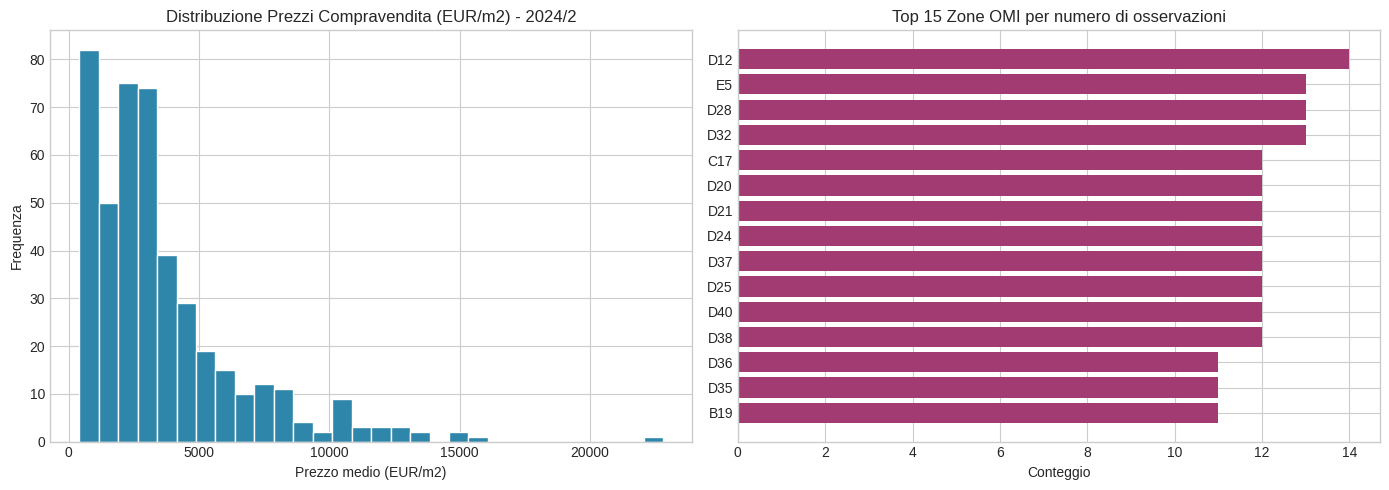

Grafico salvato. Osservazioni valide: 446/446


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BUG FIX: la media richiede colonne numeriche; ora garantite dal
# to_numeric_it applicato in fase di caricamento
omi_2024_2['Compr_avg'] = (omi_2024_2['Compr_min'] + omi_2024_2['Compr_max']) / 2

serie = omi_2024_2['Compr_avg'].dropna()
axes[0].hist(serie, bins=30, edgecolor='white', color='#2E86AB')
axes[0].set_title('Distribuzione Prezzi Compravendita (EUR/m2) - 2024/2')
axes[0].set_xlabel('Prezzo medio (EUR/m2)')
axes[0].set_ylabel('Frequenza')

zone_counts = omi_2024_2['Zona'].value_counts().head(15)
axes[1].barh(zone_counts.index.astype(str), zone_counts.values, color='#A23B72')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Zone OMI per numero di osservazioni')
axes[1].set_xlabel('Conteggio')

plt.tight_layout()
plt.savefig(PROFILING_DIR / 'omi_2024_2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafico salvato. Osservazioni valide: {len(serie)}/{len(omi_2024_2)}")

### 5.3 Profiling: OMI Storico 2004–2024

In [24]:
profile_omi_storico = profile_dataset(omi_storico, 'omi_storico_2004_2024')
print_profile_summary(profile_omi_storico, 'OMI Storico 2004-2024')

with open(PROFILING_DIR / 'omi_storico_profiling.json', 'w', encoding='utf-8') as f:
    json.dump(profile_omi_storico, f, indent=2, ensure_ascii=False)
print("\nSalvato: omi_storico_profiling.json")


PROFILING: OMI Storico 2004-2024
Righe: 26,392 | Colonne: 23
Duplicati: 0
Colonne con missing values: 1

Missing values:
  Stato: 180 (0.682%)

Outlier (metodo IQR):
  Loc_min: 1787 outlier
  Compr_min: 1755 outlier
  Loc_max: 1628 outlier
  Compr_max: 1553 outlier

Salvato: omi_storico_profiling.json


Tipologie presenti: ['Abitazioni civili' 'Abitazioni di tipo economico' 'Box'
 'Ville e Villini' 'Magazzini' 'Negozi' 'Uffici' 'Uffici strutturati']
Filtrato su tipologie residenziali: 10,175 righe


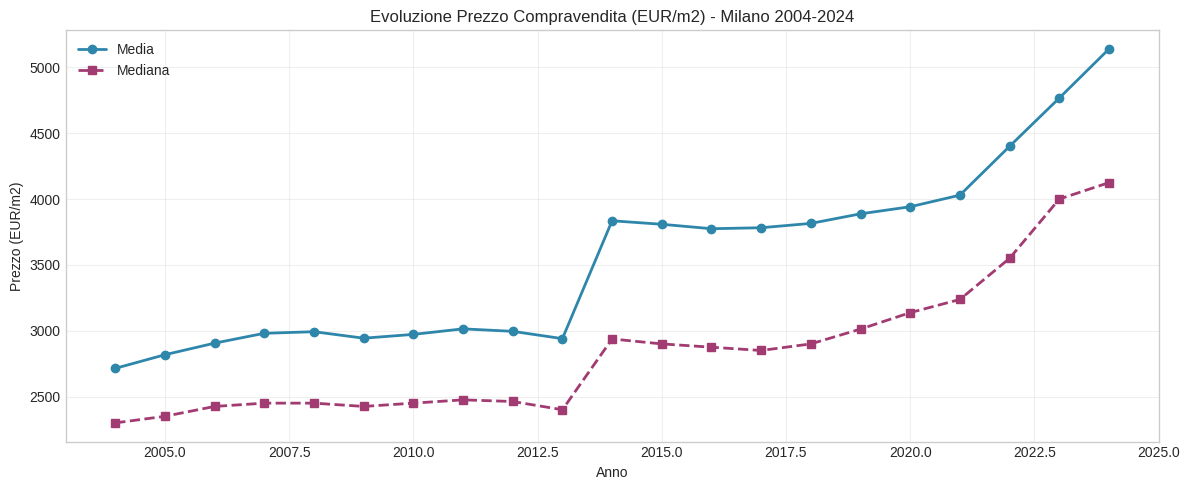

 Anno        mean  median  count
 2015 3808.665644  2900.0    326
 2016 3774.923313  2875.0    326
 2017 3782.361963  2850.0    326
 2018 3815.290520  2900.0    327
 2019 3888.109756  3012.5    328
 2020 3941.844512  3137.5    328
 2021 4029.878049  3237.5    328
 2022 4400.762195  3550.0    328
 2023 4767.378049  4000.0    328
 2024 5139.853896  4125.0    308


In [25]:
omi_storico['Compr_avg'] = (omi_storico['Compr_min'] + omi_storico['Compr_max']) / 2

# BUG FIX: l'originale filtrava con dropna(subset=['Compr_min','Compr_max'])
# e commentava "escludi locazione", ma le righe di locazione hanno comunque
# i valori di compravendita popolati in questo dataset: il filtro non
# escludeva nulla e la media annuale contava le stesse zone piu volte.
# Qui si filtra esplicitamente sulla tipologia, se la colonna esiste.
omi_compr = omi_storico.dropna(subset=['Compr_avg'])

col_tip = next((c for c in ('Descr_Tipologia', 'Tipologia')
                if c in omi_storico.columns), None)
if col_tip:
    print(f"Tipologie presenti: {omi_compr[col_tip].dropna().unique()[:8]}")
    residenziale = omi_compr[col_tip].astype(str).str.contains(
        'abitazi|residenz', case=False, na=False)
    if residenziale.any():
        omi_compr = omi_compr[residenziale]
        print(f"Filtrato su tipologie residenziali: {len(omi_compr):,} righe")

yearly = omi_compr.groupby('Anno')['Compr_avg'].agg(['mean', 'median', 'count'])
yearly = yearly[yearly['count'] >= 5].reset_index()   # scarta anni poco popolati

plt.figure(figsize=(12, 5))
plt.plot(yearly['Anno'], yearly['mean'], marker='o', linewidth=2,
         color='#2E86AB', label='Media')
plt.plot(yearly['Anno'], yearly['median'], marker='s', linewidth=2,
         color='#A23B72', linestyle='--', label='Mediana')
plt.title('Evoluzione Prezzo Compravendita (EUR/m2) - Milano 2004-2024')
plt.xlabel('Anno'); plt.ylabel('Prezzo (EUR/m2)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'omi_storico_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print(yearly.tail(10).to_string(index=False))

### 5.4 Profiling: Dati Demografici per Quartiere

In [26]:
profile_demografiche = profile_dataset(demografiche, 'demografiche_quartieri')
print_profile_summary(profile_demografiche, 'Demografiche Quartieri 2011-2023')

with open(PROFILING_DIR / 'demografiche_profiling.json', 'w', encoding='utf-8') as f:
    json.dump(profile_demografiche, f, indent=2, ensure_ascii=False)
print("\nSalvato: demografiche_profiling.json")


PROFILING: Demografiche Quartieri 2011-2023
Righe: 1,154 | Colonne: 29
Duplicati: 0
Colonne con missing values: 27

Missing values:
  Scuola secondaria di primo grado (numero): 54 (4.6794%)
  Scuola primaria (numero): 45 (3.8995%)
  Scuola dell'infanzia (numero): 39 (3.3795%)
  Terza cittadinanza: 25 (2.1664%)
  Prima cittadinanza: 23 (1.9931%)
  Seconda cittadinanza: 23 (1.9931%)
  NIL: 10 (0.8666%)
  65 e pi—: 7 (0.6066%)
  Nati fuori dal matrimonio: 6 (0.5199%)
  Immigrati: 6 (0.5199%)
  Uomini: 5 (0.4333%)
  Donne: 5 (0.4333%)
  Totale: 5 (0.4333%)
  Minori: 5 (0.4333%)
  Stranieri: 5 (0.4333%)

Outlier (metodo IQR):
  residenti prima cittadinanza: 89 outlier
  residenti seconda cittadinanza: 88 outlier
  Nati con almeno un genitore straniero: 73 outlier
  residenti terza cittadinanza: 65 outlier
  Stranieri: 50 outlier
  Area (metri quadrati): 39 outlier
  Emigrati: 30 outlier
  Immigrati: 28 outlier
  80 e pi—: 27 outlier
  Famiglie unipersonali registrate in anagrafe: 26 outlie

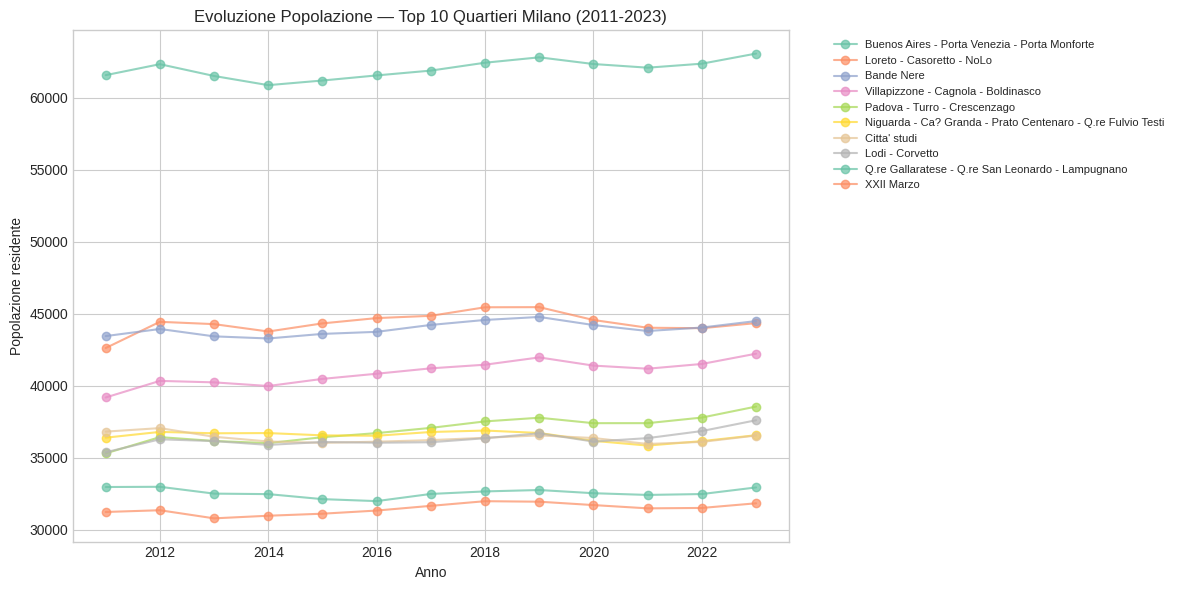

Grafico salvato: demografiche_evolution.png


In [27]:
# Evoluzione popolazione per quartiere (top 10 per popolazione)
top_quartieri = (demografiche.groupby('Quartiere')['Totale']
                 .mean().nlargest(10).index.tolist())

df_top = demografiche[demografiche['Quartiere'].isin(top_quartieri)]

plt.figure(figsize=(12, 6))
for q in top_quartieri:
    subset = df_top[df_top['Quartiere'] == q].sort_values('Anno')
    plt.plot(subset['Anno'], subset['Totale'], marker='o', label=q, alpha=0.7)

plt.title('Evoluzione Popolazione — Top 10 Quartieri Milano (2011-2023)')
plt.xlabel('Anno')
plt.ylabel('Popolazione residente')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(PROFILING_DIR / 'demografiche_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato: demografiche_evolution.png")

### 5.5 Profiling: Annunci di vendita e locazioni brevi

In [28]:
profile_listings = profile_dataset(df_listings, 'annunci_vendita')
print_profile_summary(profile_listings, 'Annunci di vendita (API Idealista)')

with open(PROFILING_DIR / 'annunci_vendita_profiling.json', 'w', encoding='utf-8') as f:
    json.dump(profile_listings, f, indent=2, ensure_ascii=False)

# Profiling del dataset Airbnb
profile_airbnb = profile_dataset(df_airbnb, 'airbnb_milano')
print_profile_summary(profile_airbnb, 'Inside Airbnb Milano')

with open(PROFILING_DIR / 'airbnb_milano_profiling.json', 'w', encoding='utf-8') as f:
    json.dump(profile_airbnb, f, indent=2, ensure_ascii=False)

print("\nSalvati: annunci_vendita_profiling.json, airbnb_milano_profiling.json")


PROFILING: Annunci di vendita (API Idealista)
Righe: 301 | Colonne: 14
Duplicati: 0
Colonne con missing values: 2

Missing values:
  listing_date: 301 (100.0%)
  floor: 1 (0.3322%)

Outlier (metodo IQR):
  price_eur: 28 outlier
  rooms: 25 outlier
  area_m2: 15 outlier
  price_per_m2_eur: 13 outlier
  bathrooms: 5 outlier

PROFILING: Inside Airbnb Milano
Righe: 22,540 | Colonne: 19
Duplicati: 0
Colonne con missing values: 5

Missing values:
  neighbourhood_group: 22540 (100.0%)
  license: 3476 (15.4215%)
  last_review: 3425 (15.1952%)
  reviews_per_month: 3425 (15.1952%)
  price: 2087 (9.2591%)

Outlier (metodo IQR):
  minimum_nights: 4452 outlier
  calculated_host_listings_count: 3682 outlier
  number_of_reviews: 2462 outlier
  number_of_reviews_ltm: 2198 outlier
  price: 1745 outlier
  reviews_per_month: 956 outlier
  longitude: 292 outlier
  latitude: 34 outlier

Salvati: annunci_vendita_profiling.json, airbnb_milano_profiling.json


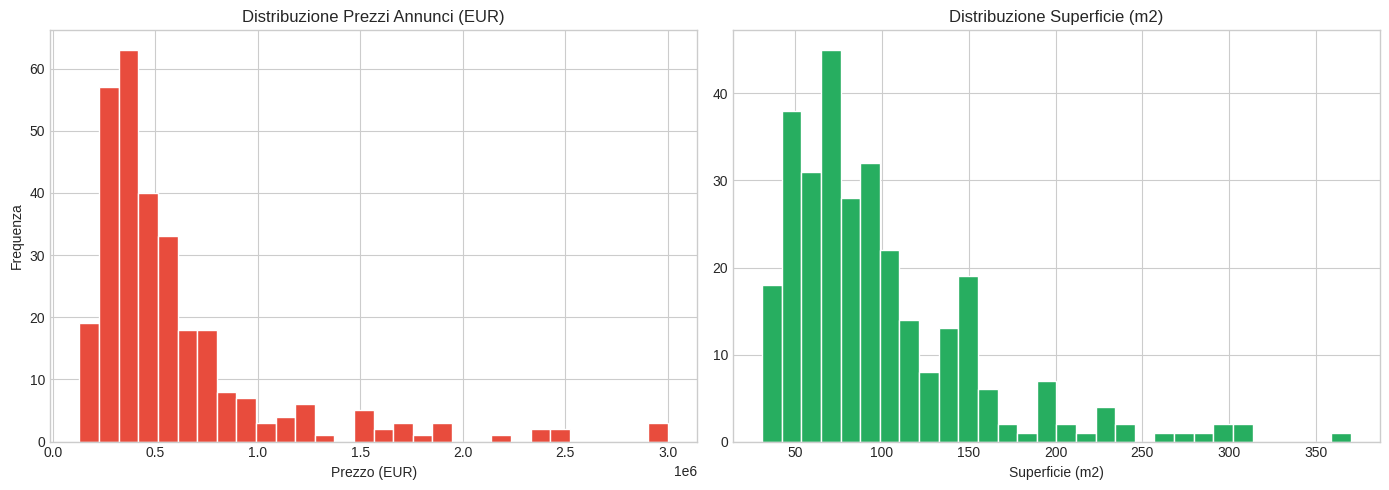

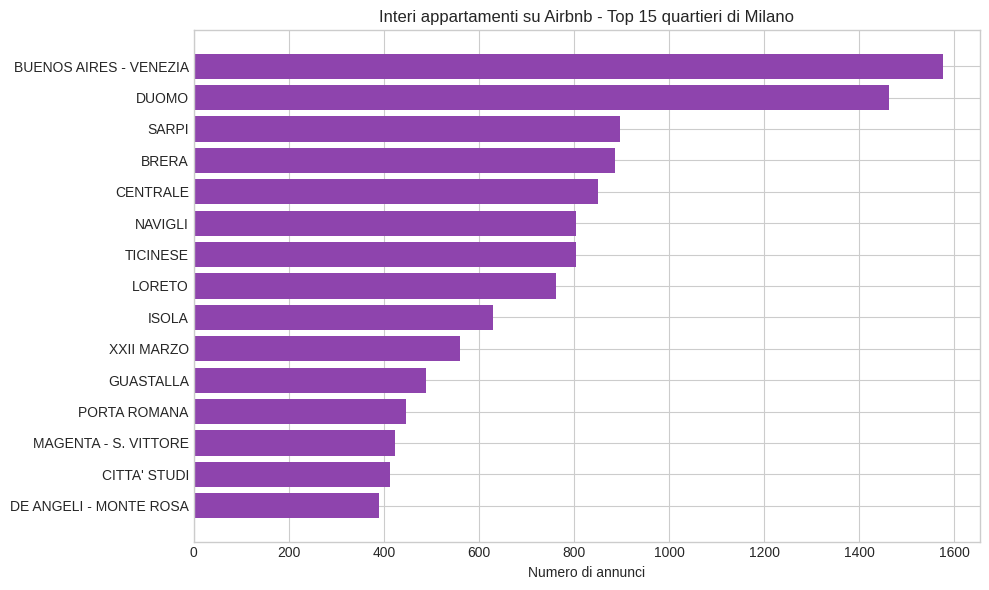

In [29]:
# BUG FIX: senza questa guardia, con df_listings vuoto la cella
# sollevava un errore su hist() di una serie senza dati.
if df_listings['price_eur'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df_clean = df_listings[df_listings['price_eur'].between(1, 3_000_000)]
    axes[0].hist(df_clean['price_eur'].dropna(), bins=30,
                 edgecolor='white', color='#E84C3D')
    axes[0].set_title('Distribuzione Prezzi Annunci (EUR)')
    axes[0].set_xlabel('Prezzo (EUR)'); axes[0].set_ylabel('Frequenza')

    df_area = df_listings[df_listings['area_m2'].between(1, 500)]
    axes[1].hist(df_area['area_m2'].dropna(), bins=30,
                 edgecolor='white', color='#27AE60')
    axes[1].set_title('Distribuzione Superficie (m2)')
    axes[1].set_xlabel('Superficie (m2)')

    plt.tight_layout()
    plt.savefig(PROFILING_DIR / 'listings_distribution.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Nessun annuncio di vendita: grafico saltato.")

# Grafico Airbnb per quartiere: densita di interi appartamenti
if not df_airbnb.empty and {'neighbourhood', 'room_type'} <= set(df_airbnb.columns):
    interi = df_airbnb[df_airbnb['room_type'] == 'Entire home/apt']
    top = interi['neighbourhood'].value_counts().head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(top.index.astype(str), top.values, color='#8E44AD')
    plt.gca().invert_yaxis()
    plt.title('Interi appartamenti su Airbnb - Top 15 quartieri di Milano')
    plt.xlabel('Numero di annunci')
    plt.tight_layout()
    plt.savefig(PROFILING_DIR / 'airbnb_by_neighbourhood.png',
                dpi=150, bbox_inches='tight')
    plt.show()

OUTLIER E INCOERENZE NEGLI ANNUNCI DI VENDITA
  Prezzo mancante o nullo: 0
  Superficie < 10 m2:      0
  Prezzo/m2 > 30.000 EUR:  0
  Prezzo/m2 < 500 EUR:     0
  Locali mancanti o zero:  0


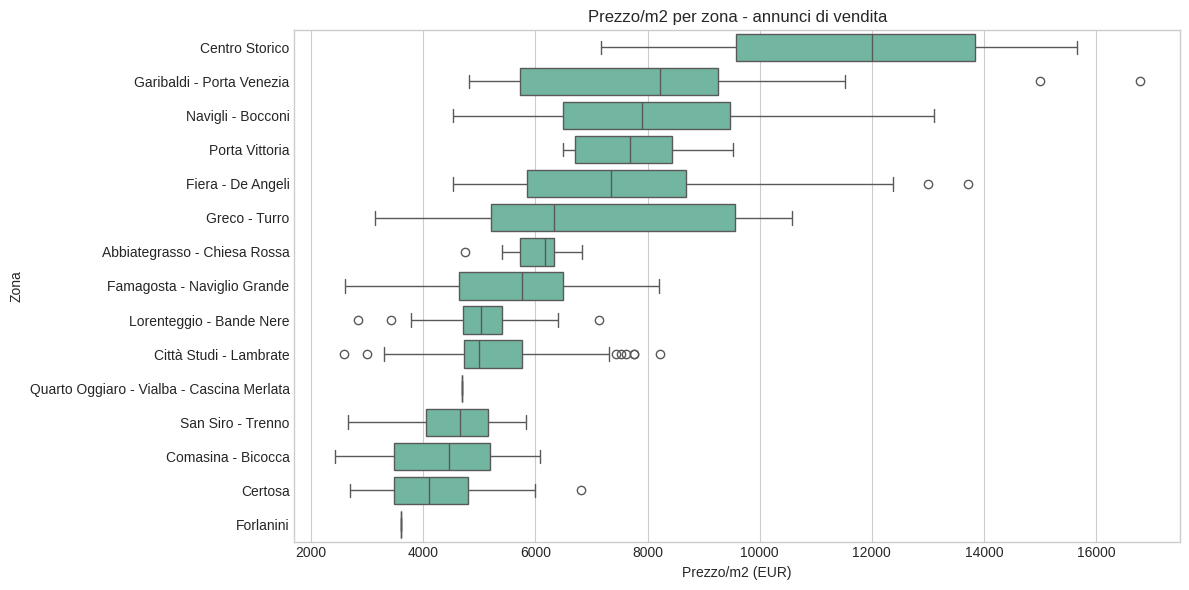


OUTLIER E INCOERENZE SU AIRBNB
  Prezzo/notte mancante: 2087
  Prezzo/notte > 1.000 EUR: 211
  Disponibilita 0 giorni/anno: 1610
  Quota annunci di host multi-proprieta: 62.6%


In [30]:
print("OUTLIER E INCOERENZE NEGLI ANNUNCI DI VENDITA")
if df_listings.empty:
    print("  Dataset vuoto.")
else:
    p, a, ppm = df_listings['price_eur'], df_listings['area_m2'], df_listings['price_per_m2_eur']
    print(f"  Prezzo mancante o nullo: {int((p.isna() | p.eq(0)).sum())}")
    print(f"  Superficie < 10 m2:      {int(a.lt(10).sum())}")
    print(f"  Prezzo/m2 > 30.000 EUR:  {int(ppm.gt(30000).sum())}")
    print(f"  Prezzo/m2 < 500 EUR:     {int(ppm.lt(500).sum())}")
    print(f"  Locali mancanti o zero:  "
          f"{int((df_listings['rooms'].isna() | df_listings['rooms'].eq(0)).sum())}")

    df_plot = df_listings[ppm.between(500, 20000)]
    if len(df_plot) >= 10:
        ordine = (df_plot.groupby('zone_neighborhood')['price_per_m2_eur']
                  .median().sort_values(ascending=False).index[:15])
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df_plot[df_plot['zone_neighborhood'].isin(ordine)],
                    x='price_per_m2_eur', y='zone_neighborhood', order=ordine)
        plt.title('Prezzo/m2 per zona - annunci di vendita')
        plt.xlabel('Prezzo/m2 (EUR)'); plt.ylabel('Zona')
        plt.tight_layout()
        plt.savefig(PROFILING_DIR / 'listings_price_by_zone.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("\n  Dati insufficienti per il boxplot per zona.")

print("\nOUTLIER E INCOERENZE SU AIRBNB")
if df_airbnb.empty:
    print("  Dataset vuoto.")
else:
    print(f"  Prezzo/notte mancante: {int(df_airbnb['price'].isna().sum())}")
    print(f"  Prezzo/notte > 1.000 EUR: {int(df_airbnb['price'].gt(1000).sum())}")
    print(f"  Disponibilita 0 giorni/anno: "
          f"{int(df_airbnb.get('availability_365', pd.Series(dtype=float)).eq(0).sum())}")
    if 'host_multi_listing' in df_airbnb.columns:
        quota = df_airbnb['host_multi_listing'].mean() * 100
        print(f"  Quota annunci di host multi-proprieta: {quota:.1f}%")

### 5.6 Incoerenze nei nomi delle zone

Uno dei problemi principali è il **mismatch tra i nomi zona** delle diverse fonti: OMI usa codici alfanumerici (B12, C15...), il dataset demografico usa nomi di quartiere/NIL, e gli annunci immobiliari usano testo libero. Serve una tabella di mapping.

In [31]:
print("Zone OMI (dataset storico):")
print(omi_storico['Zona'].dropna().unique()[:15])
print(f"Totale zone OMI: {omi_storico['Zona'].nunique()}\n")

print("Quartieri (dataset demografico, NIL):")
print(demografiche['Quartiere'].dropna().unique()[:15])
print(f"Totale quartieri: {demografiche['Quartiere'].nunique()}\n")

print("Zone negli annunci di vendita:")
if df_listings.empty:
    print("  (nessun annuncio acquisito)")
else:
    print(df_listings['zone_neighborhood'].dropna().unique()[:15])
    print(f"Totale: {df_listings['zone_neighborhood'].nunique()}")

print("\nQuartieri Inside Airbnb:")
if df_airbnb.empty or 'neighbourhood' not in df_airbnb.columns:
    print("  (dataset non disponibile)")
else:
    print(df_airbnb['neighbourhood'].dropna().unique()[:15])
    print(f"Totale: {df_airbnb['neighbourhood'].nunique()}")

    # I quartieri Inside Airbnb seguono i NIL: verifichiamo la sovrapposizione
    nil_demo = set(demografiche['Quartiere'].dropna().str.upper().str.strip())
    nil_bnb = set(df_airbnb['neighbourhood'].dropna().str.upper().str.strip())
    comuni = nil_demo & nil_bnb
    print(f"\nNIL in comune demografiche <-> Airbnb: {len(comuni)}")
    print(f"Solo in Airbnb: {sorted(nil_bnb - nil_demo)[:10]}")

Zone OMI (dataset storico):
['B01' 'B02' 'B03' 'B04' 'B05' 'B06' 'B11' 'B12' 'B13' 'B14' 'C01' 'C02'
 'C03' 'C04' 'C05']
Totale zone OMI: 85

Quartieri (dataset demografico, NIL):
['Adriano' 'Affori' 'Assiano' 'Baggio - Q.re degli Olmi - Q.re Valsesia'
 'Bande Nere' 'Barona' 'Bicocca' 'Bovisa' 'Bovisasca' 'Brera' 'Bruzzano'
 'Buenos Aires - Porta Venezia - Porta Monforte' 'Cantalupa'
 'Cascina Merlata' 'Chiaravalle']
Totale quartieri: 89

Zone negli annunci di vendita:
['Navigli - Bocconi' 'Garibaldi - Porta Venezia' 'Fiera - De Angeli'
 'Centro Storico' 'Porta Vittoria' 'Comasina - Bicocca' 'Greco - Turro'
 'Abbiategrasso - Chiesa Rossa' 'Lorenteggio - Bande Nere'
 'Famagosta - Naviglio Grande' 'Città Studi - Lambrate' 'Forlanini'
 'Lorenteggio' 'Certosa' 'Quarto Oggiaro - Vialba - Cascina Merlata']
Totale: 16

Quartieri Inside Airbnb:
['NAVIGLI' 'VIALE MONZA' 'VILLAPIZZONE' 'XXII MARZO' 'STADERA'
 'S. CRISTOFORO' 'GIAMBELLINO' 'DUOMO' 'BUENOS AIRES - VENEZIA' 'TORTONA'
 'UMBRIA - MOL

## 6. Sintesi del Data Profiling

Riepilogo dei problemi identificati in ogni dataset e azioni correttive necessarie per la fase ETL.

In [32]:
# BUG FIX METODOLOGICO: l'originale scriveva a mano numeri come
# "Compr_min: 32", "Stato: 180 (0.68%)", "floor: 16.7%", "Duplicati: 0".
# Erano valori copiati da un'esecuzione precedente e non ricalcolati:
# se i dati cambiano, la tabella di sintesi mente. Ora tutto deriva
# dai dizionari di profiling.

profili = [
    ('OMI Compravendita 2024/2', profile_omi_2024,
     'Outlier nei prezzi estremi (centro storico)'),
    ('OMI Storico 2004-2024', profile_omi_storico,
     'Serie ventennale: outlier fisiologici, verificare tipologia'),
    ('Demografiche Quartieri', profile_demografiche,
     'Granularita NIL, da mappare sulle zone OMI'),
    ('Annunci vendita', profile_listings,
     'Zone testuali da normalizzare'),
    ('Inside Airbnb Milano', profile_airbnb,
     'Prezzo per notte: non confrontabile con EUR/m2 di vendita'),
]

righe = [{
    'Dataset': nome,
    'Righe': p['row_count'],
    'Col. con missing': p['missing_columns'],
    'Missing principali': missing_string(p),
    'Duplicati': p['duplicate_rows'],
    'Outlier (IQR)': outlier_string(p),
    'Note': nota,
} for nome, p, nota in profili]

righe.append({
    'Dataset': 'Perimetri Zone OMI',
    'Righe': len(geo_data['features']),
    'Col. con missing': 0,
    'Missing principali': 'n/d (GeoJSON)',
    'Duplicati': 0,
    'Outlier (IQR)': 'n/d',
    'Note': 'Snapshot 2024/1 non allineato alle quotazioni 2024/2',
})

sintesi = pd.DataFrame(righe)
sintesi

,Dataset,Righe,Col. con missing,Missing principali,Duplicati,Outlier (IQR),Note
0,OMI Compravendita 2024/2,446,0,Nessuno,0,"Compr_min: 32, Compr_max: 29",Outlier nei prezzi estremi (centro storico)
1,OMI Storico 2004-2024,26392,1,Stato: 0.682%,0,"Loc_min: 1787, Compr_min: 1755","Serie ventennale: outlier fisiologici, verific..."
2,Demografiche Quartieri,1154,27,Scuola secondaria di primo grado (numero): 4.6...,0,"residenti prima cittadinanza: 89, residenti se...","Granularita NIL, da mappare sulle zone OMI"
3,Annunci vendita,301,2,"listing_date: 100.0%, floor: 0.3322%",0,"price_eur: 28, rooms: 25",Zone testuali da normalizzare
4,Inside Airbnb Milano,22540,5,"neighbourhood_group: 100.0%, license: 15.4215%",0,"minimum_nights: 4452, calculated_host_listings...",Prezzo per notte: non confrontabile con EUR/m2...
5,Perimetri Zone OMI,41,0,n/d (GeoJSON),0,n/d,Snapshot 2024/1 non allineato alle quotazioni ...


In [33]:
# La tabella markdown viene generata dallo stesso DataFrame calcolato sopra
md_tabella = sintesi.to_markdown(index=False)

md_content = f"""# Sintesi Data Profiling - Gentrificazione Milano

Generato automaticamente dai profili JSON in `{PROFILING_DIR}`.

{md_tabella}

## Nota sulle fonti degli annunci

Immobiliare.it e Idealista.it proteggono le pagine pubbliche con sistemi di
bot-detection e ne vietano l'estrazione automatizzata nei Termini di Servizio.
Gli annunci di vendita sono quindi acquisiti tramite l'**API ufficiale di
Idealista** (accesso ricerca), e la pressione da locazione breve tramite
**Inside Airbnb** (CC BY 4.0). La serie storica dei prezzi, che e il dato
centrale per misurare la gentrificazione, viene dall'**OMI** dell'Agenzia
delle Entrate: copre vent'anni, cosa che nessuno snapshot di annunci puo fare.

## Azioni correttive per la fase ETL

1. **Normalizzare i nomi zona**: costruire la tabella di mapping
   zona OMI <-> NIL <-> quartiere Airbnb. E il collo di bottiglia dell'intero
   progetto: senza chiave comune i dataset non si uniscono.
2. **Gestire i missing**: eliminare le righe senza prezzo o senza zona;
   imputare solo i campi non critici (piano, bagni).
3. **Filtrare gli outlier**: prezzo/m2 fuori dall'intervallo 500-30.000 EUR,
   superficie < 10 m2, prezzo/notte Airbnb > 1.000 EUR.
4. **Allineare le granularita temporali**: OMI e semestrale, le demografiche
   sono annuali (2011-2023), gli annunci sono uno snapshot puntuale.
5. **Non mescolare unita di misura**: EUR/m2 di compravendita, EUR/mese di
   locazione e EUR/notte di Airbnb vanno tenuti su assi separati.
6. **Documentare la data di estrazione** di ogni fonte per la riproducibilita.
"""

with open(PROFILING_DIR / 'profiling_summary.md', 'w', encoding='utf-8') as f:
    f.write(md_content)
print("Salvato: profiling_summary.md\n")
print(md_content)

Salvato: profiling_summary.md

# Sintesi Data Profiling - Gentrificazione Milano

Generato automaticamente dai profili JSON in `data/milano-realestate/profiling`.

| Dataset                  |   Righe |   Col. con missing | Missing principali                                                                    |   Duplicati | Outlier (IQR)                                                        | Note                                                        |
|:-------------------------|--------:|-------------------:|:--------------------------------------------------------------------------------------|------------:|:---------------------------------------------------------------------|:------------------------------------------------------------|
| OMI Compravendita 2024/2 |     446 |                  0 | Nessuno                                                                               |           0 | Compr_min: 32, Compr_max: 29                                         | Outlier nei p

## 7. Verifica file salvati

In [34]:
# Verifica che tutti i file raw e profiling esistano
print("FILE RAW:")
for f in sorted(RAW_DIR.iterdir()):
    size = f.stat().st_size
    print(f"  {f.name:40s} {size:>10,} bytes")

print(f"\nFILE PROFILING:")
for f in sorted(PROFILING_DIR.iterdir()):
    size = f.stat().st_size
    print(f"  {f.name:40s} {size:>10,} bytes")

print(f"\nTotale file raw: {len(list(RAW_DIR.iterdir()))}")
print(f"Totale file profiling: {len(list(PROFILING_DIR.iterdir()))}")

FILE RAW:
  airbnb_milano_listings.csv                3,842,927 bytes
  annunci_vendita.csv                         209,139 bytes
  demografiche_quartieri.csv                  183,049 bytes
  omi_compravendita_2024_2.csv                 47,976 bytes
  omi_storico_2004_2024.csv                 3,545,998 bytes
  omi_zone_perimetri.geojson                  364,358 bytes

FILE PROFILING:
  airbnb_by_neighbourhood.png                  67,488 bytes
  airbnb_milano_profiling.json                  5,197 bytes
  annunci_vendita_profiling.json                3,167 bytes
  demografiche_evolution.png                  163,597 bytes
  demografiche_profiling.json                   9,318 bytes
  listings_distribution.png                    45,686 bytes
  listings_price_by_zone.png                   92,939 bytes
  omi_2024_2_distribution.png                  68,831 bytes
  omi_compravendita_2024_2_profiling.json       3,582 bytes
  omi_storico_evolution.png                    80,297 bytes
  omi_storico

## Riepilogo Fase 1

| Step | Cosa e stato fatto | Output |
|---|---|---|
| Download OMI 2024/2 | Quotazioni compravendita semestre corrente | `raw/omi_compravendita_2024_2.csv` |
| Download OMI storico | Serie 2004-2024 compravendita + locazione | `raw/omi_storico_2004_2024.csv` |
| Download perimetri | Confini geografici zone OMI | `raw/omi_zone_perimetri.geojson` |
| Download demografiche | Indicatori per NIL 2011-2023 | `raw/demografiche_quartieri.csv` |
| Annunci di vendita | **API ufficiale Idealista** (OAuth2) | `raw/annunci_vendita.csv` |
| Locazioni brevi | **Inside Airbnb** Milano, CC BY 4.0 | `raw/airbnb_milano_listings.csv` |
| Serie prezzi richiesti | **Immobiliare.it Insights** / Market Explorer (contratto B2B) | `raw/immobiliare_insights_prezzi.csv` |
| Mix commerciale | OpenStreetMap / Overpass (opzionale) | `raw/osm_poi_milano.csv` |
| Data profiling | Struttura, missing, duplicati, outlier | JSON + PNG + `profiling_summary.md` |

### Correzioni rispetto alla versione precedente

1. **Sostituito lo scraping anti-bot** di Immobiliare.it e Idealista.it con
   le rispettive API ufficiali e con altre fonti ad accesso consentito. Il codice originale usava
   `undetected-chromedriver`, `playwright-stealth` e un browser non-headless su
   display virtuale per eludere Datadome: oltre a violare i Termini di
   Servizio, rendeva il notebook non riproducibile in sede di valutazione.
2. **Encoding e separatore decimale**: i CSV del Comune venivano letti come
   UTF-8 con decimale punto. Da qui sia il "mojibake" nelle etichette (che il
   notebook classificava erroneamente come difetto del dataset) sia le colonne
   di prezzo rimaste di tipo `object`.
3. **DataFrame senza colonne**: con lo scraping a vuoto, `pd.DataFrame([])`
   generava `KeyError: 'price_eur'` e bloccava tutto il profiling.
4. **Numeri della sintesi ricalcolati** invece che scritti a mano.
5. **Filtro compravendita/locazione** nella serie storica, che prima non
   escludeva nulla.
6. **Deduplica effettiva** degli annunci, prima solo dichiarata.

### Problemi aperti per la Fase 2

1. **Mismatch delle chiavi geografiche**: zone OMI (codici) vs NIL (nomi) vs
   quartieri Airbnb. Serve una tabella di mapping, possibilmente costruita
   via intersezione spaziale tra il GeoJSON OMI e i confini NIL.
2. **Disallineamento temporale** tra perimetri 2024/1 e quotazioni 2024/2.
3. **Copertura degli annunci** limitata dal rate limit dell'API gratuita:
   vanno scelte poche zone rappresentative invece di coprire tutta la citta.